In [ ]:
# CELL 1: SETUP
!pip install inflect -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10,6)

In [ ]:
import pandas as pd

df = pd.read_csv("spotify dataset.csv")  # use 'df' everywhere now
df.head()

,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,6f807x0ima9a1j3VPbc7VN,I Don't Care (with Justin Bieber) - Loud Luxur...,Ed Sheeran,66,2oCs0DGTsRO98Gh5ZSl2Cx,I Don't Care (with Justin Bieber) [Loud Luxury...,2019-06-14,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,6,-2.634,1,0.0583,0.1020,0.000000,0.0653,0.518,122.036,194754
1,0r7CVbZTWZgbTCYdfa2P31,Memories - Dillon Francis Remix,Maroon 5,67,63rPSO264uRjW1X5E6cWv6,Memories (Dillon Francis Remix),2019-12-13,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,11,-4.969,1,0.0373,0.0724,0.004210,0.3570,0.693,99.972,162600
2,1z1Hg7Vb0AhHDiEmnDE79l,All the Time - Don Diablo Remix,Zara Larsson,70,1HoSmj2eLcsrR0vE9gThr4,All the Time (Don Diablo Remix),2019-07-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-3.432,0,0.0742,0.0794,0.000023,0.1100,0.613,124.008,176616
3,75FpbthrwQmzHlBJLuGdC7,Call You Mine - Keanu Silva Remix,The Chainsmokers,60,1nqYsOef1yKKuGOVchbsk6,Call You Mine - The Remixes,2019-07-19,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,7,-3.778,1,0.1020,0.0287,0.000009,0.2040,0.277,121.956,169093
4,1e8PAfcKUYoKkxPhrHqw4x,Someone You Loved - Future Humans Remix,Lewis Capaldi,69,7m7vv9wlQ4i0LFuJiE2zsQ,Someone You Loved (Future Humans Remix),2019-03-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-4.672,1,0.0359,0.0803,0.000000,0.0833,0.725,123.976,189052


In [ ]:
# CELL 3: DATA CLEANING
print("Shape:", df.shape)
print("Missing values:\n", df.isnull().sum())

df.fillna(df.mean(numeric_only=True), inplace=True)  # changed data -> df
df.drop_duplicates(inplace=True)  # changed data -> df

print("Shape after cleaning:", df.shape)

Shape: (4348, 23)
Missing values:
 track_id                    0
track_name                  0
track_artist                0
track_popularity            0
track_album_id              0
track_album_name            0
track_album_release_date    0
playlist_name               0
playlist_id                 0
playlist_genre              0
playlist_subgenre           0
danceability                0
energy                      0
key                         0
loudness                    0
mode                        0
speechiness                 0
acousticness                0
instrumentalness            0
liveness                    0
valence                     0
tempo                       0
duration_ms                 0
dtype: int64
Shape after cleaning: (4348, 23)


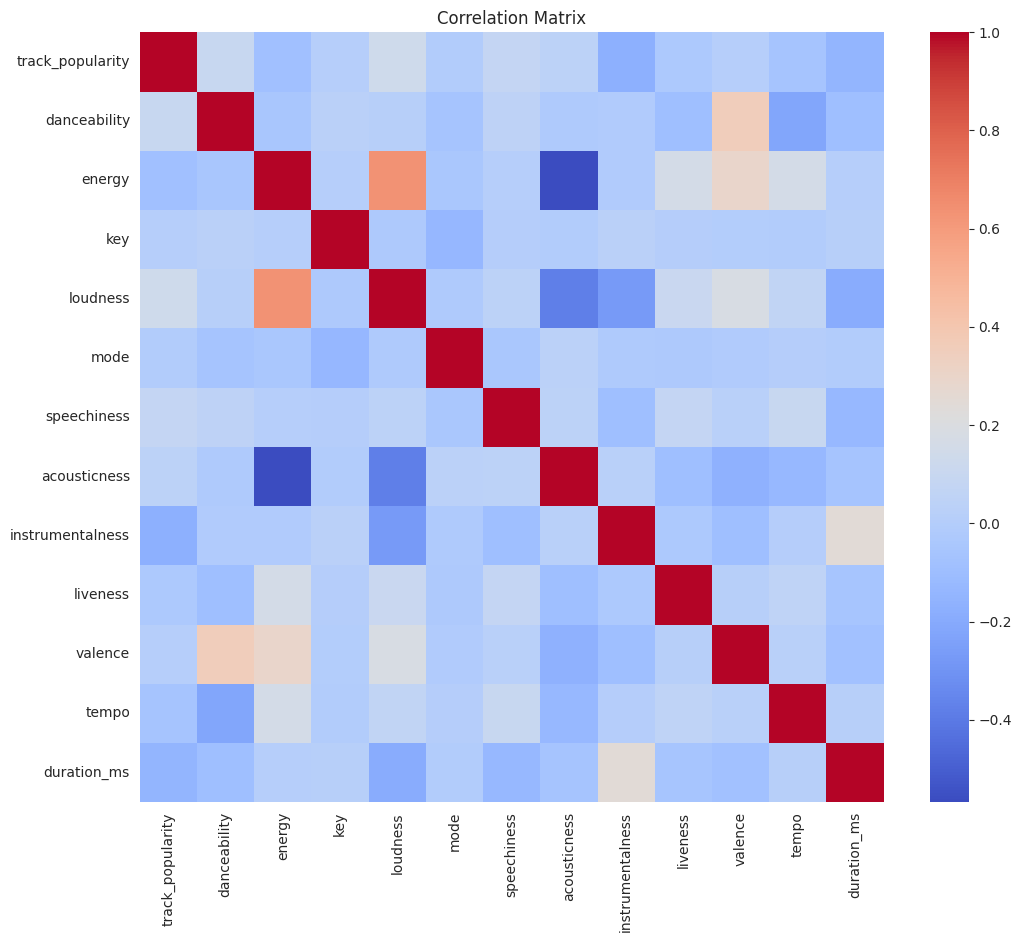

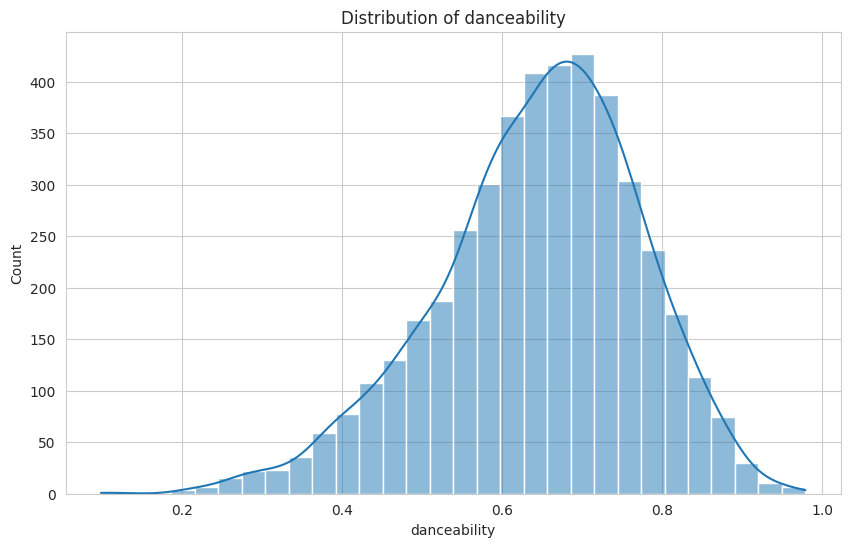

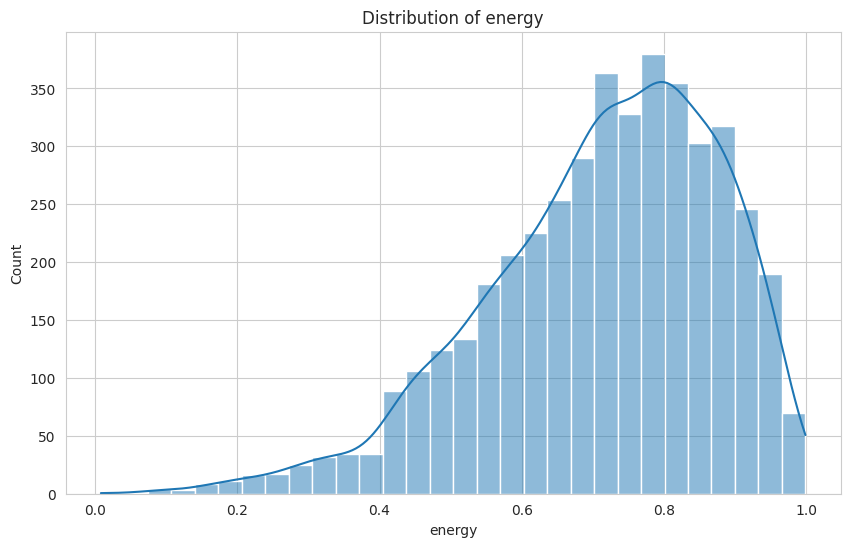

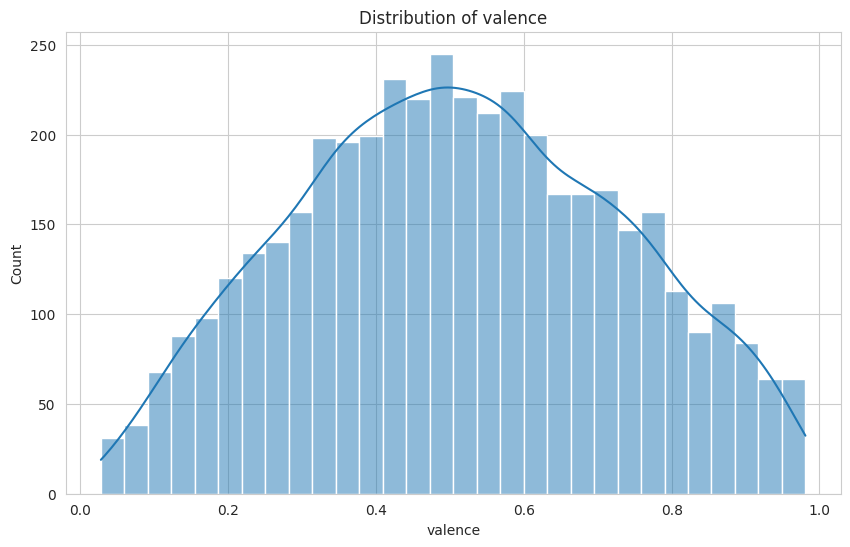

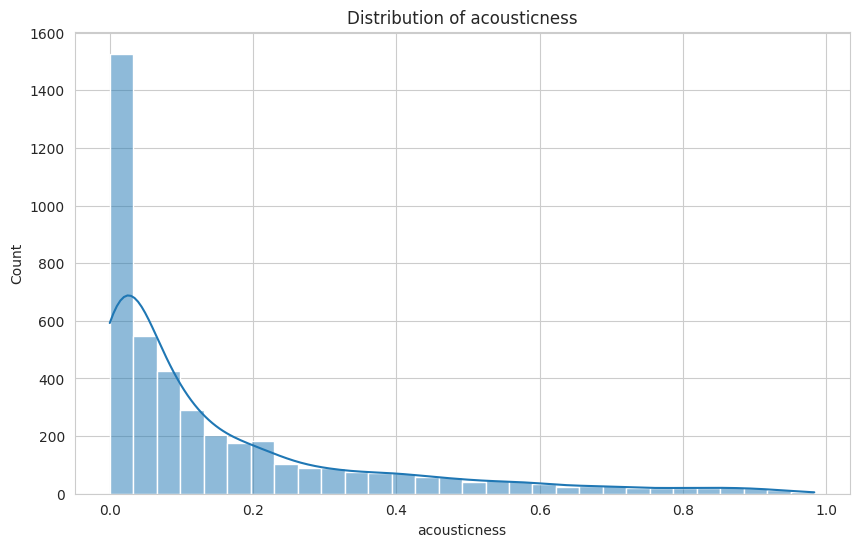

In [ ]:
# CELL 4: EDA - CORRELATION + DISTRIBUTION
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(numeric_only=True), annot=False, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

for col in ['danceability','energy','valence','acousticness']:
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f"Distribution of {col}")
    plt.show()

In [ ]:
# CELL 5: PREPROCESSING - SELECT AUDIO FEATURES ONLY
features = ['danceability','energy','loudness','speechiness',
            'acousticness','instrumentalness','liveness',
            'valence','tempo']

X = df[features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

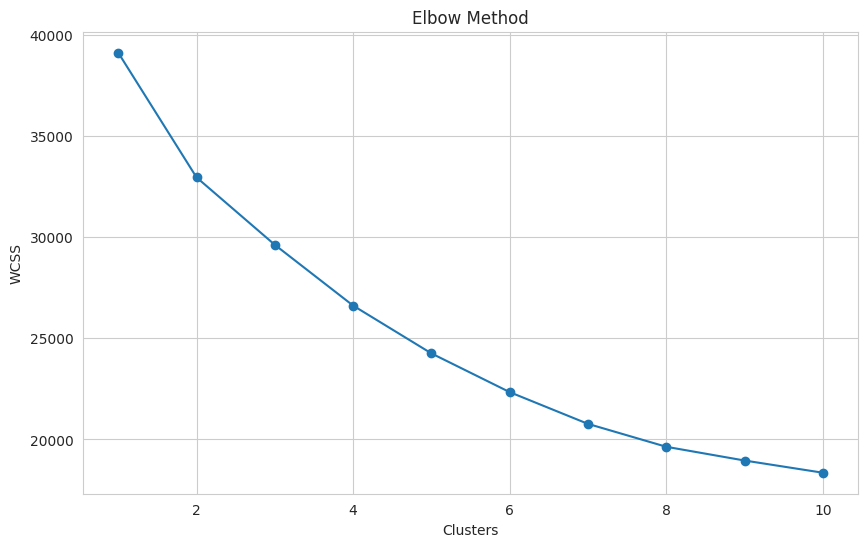

In [ ]:
# CELL 6: ELBOW METHOD
wcss = []
for i in range(1,11):
    model = KMeans(n_clusters=i, random_state=42, n_init=10)
    model.fit(X_scaled)
    wcss.append(model.inertia_)

plt.plot(range(1,11), wcss, marker='o')
plt.xlabel("Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [ ]:
# CELL 7: KMEANS + EVALUATION
optimal_k = 5 # Pick from elbow plot. Usually 4-6 for this dataset
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(X_scaled)

print("Silhouette Score:", silhouette_score(X_scaled, df["Cluster"]))

Silhouette Score: 0.1578081186597157


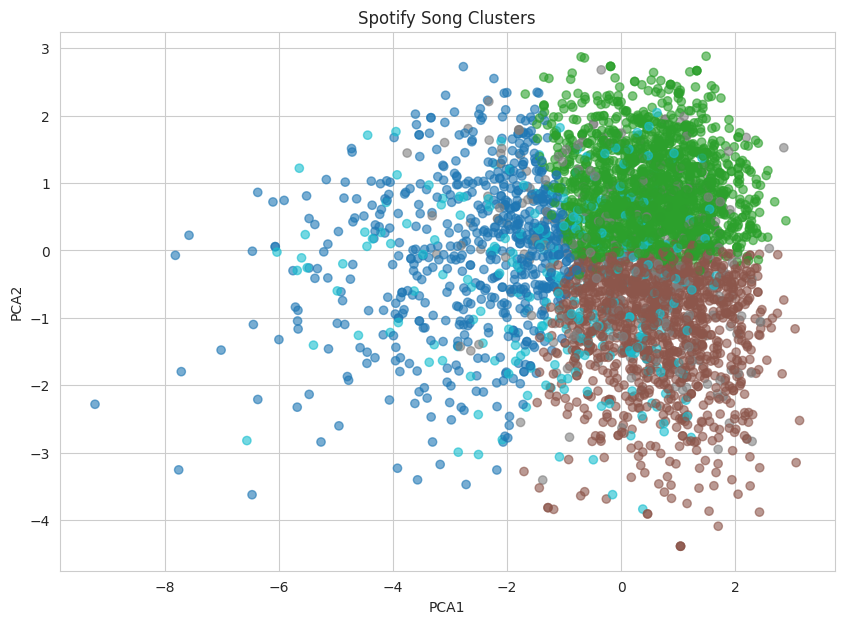

In [ ]:
# CELL 8: PCA VISUALIZATION
pca = PCA(n_components=2)
principal = pca.fit_transform(X_scaled)

plt.figure(figsize=(10,7))
plt.scatter(principal[:,0], principal[:,1], c=df["Cluster"], cmap='tab10', alpha=0.6)
plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.title("Spotify Song Clusters")
plt.show()

Cluster           0     1     2    3    4
playlist_genre                           
pop             642  1804  1329  299  274


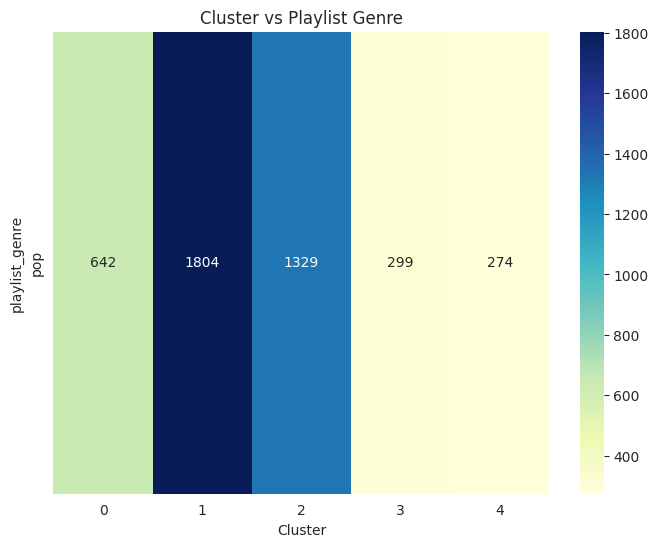

In [ ]:
# CELL 9: COMPARE CLUSTERS WITH ACTUAL GENRE - MOST IMPORTANT
# Using playlist_genre from your dataset
crosstab = pd.crosstab(df["playlist_genre"], df["Cluster"])
print(crosstab)

plt.figure(figsize=(8,6))
sns.heatmap(crosstab, annot=True, fmt='d', cmap="YlGnBu")
plt.title("Cluster vs Playlist Genre")
plt.show()

In [ ]:
# CELL 10: RECOMMENDATION SYSTEM
def recommend_songs(song_name, df, top_n=10):
    if song_name not in df['track_name'].values:
        return "Song not found"
    cluster = df[df["track_name"] == song_name]["Cluster"].values[0]
    print(f"'{song_name}' belongs to Cluster {cluster}\n")
    recommendations = df[df["Cluster"] == cluster]
    recommendations = recommendations[recommendations["track_name"]!= song_name]
    return recommendations[["track_name","track_artist","playlist_genre"]].head(top_n)

recommend_songs("I Don't Care", df)

'Song not found'

In [ ]:
# CELL 11: SAVE
df.to_csv("Spotify_Clustered_Results.csv", index=False)
files.download("Spotify_Clustered_Results.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pickle
import joblib

# Save the trained KMeans model and scaler
joblib.dump(model, 'kmeans_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
df.to_csv('Spotify_Clustered_Results.csv', index=False)

from google.colab import files
files.download('kmeans_model.pkl')
files.download('scaler.pkl')
files.download('Spotify_Clustered_Results.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files
files.download('scaler.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>